https://github.com/karpathy/makemore/tree/master

In [3]:
words = open('names.txt', 'r').read().splitlines()

In [4]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [5]:
len(words)

32033

In [6]:
min(len(w) for w in words)

2

In [7]:
max(len(w) for w in words)

15

In [8]:
#bigram language model - look at 2 charachters to predict the next charachter in the sequence. #simple starting model

In [16]:
b ={}
for w in words:
    chs  = ['<S>'] + list(w) + ['<E>'] #special start and end charachter.
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram, 0) + 1
        print(ch1,ch2)

<S> e
e m
m m
m a
a <E>
<S> o
o l
l i
i v
v i
i a
a <E>
<S> a
a v
v a
a <E>
<S> i
i s
s a
a b
b e
e l
l l
l a
a <E>
<S> s
s o
o p
p h
h i
i a
a <E>
<S> c
c h
h a
a r
r l
l o
o t
t t
t e
e <E>
<S> m
m i
i a
a <E>
<S> a
a m
m e
e l
l i
i a
a <E>
<S> h
h a
a r
r p
p e
e r
r <E>
<S> e
e v
v e
e l
l y
y n
n <E>
<S> a
a b
b i
i g
g a
a i
i l
l <E>
<S> e
e m
m i
i l
l y
y <E>
<S> e
e l
l i
i z
z a
a b
b e
e t
t h
h <E>
<S> m
m i
i l
l a
a <E>
<S> e
e l
l l
l a
a <E>
<S> a
a v
v e
e r
r y
y <E>
<S> s
s o
o f
f i
i a
a <E>
<S> c
c a
a m
m i
i l
l a
a <E>
<S> a
a r
r i
i a
a <E>
<S> s
s c
c a
a r
r l
l e
e t
t t
t <E>
<S> v
v i
i c
c t
t o
o r
r i
i a
a <E>
<S> m
m a
a d
d i
i s
s o
o n
n <E>
<S> l
l u
u n
n a
a <E>
<S> g
g r
r a
a c
c e
e <E>
<S> c
c h
h l
l o
o e
e <E>
<S> p
p e
e n
n e
e l
l o
o p
p e
e <E>
<S> l
l a
a y
y l
l a
a <E>
<S> r
r i
i l
l e
e y
y <E>
<S> z
z o
o e
e y
y <E>
<S> n
n o
o r
r a
a <E>
<S> l
l i
i l
l y
y <E>
<S> e
e l
l e
e a
a n
n o
o r
r <E>
<S> h
h a
a n
n n
n a
a 

In [17]:
#count the combinations of these combinations
b

{('<S>', 'e'): 1531,
 ('e', 'm'): 769,
 ('m', 'm'): 168,
 ('m', 'a'): 2590,
 ('a', '<E>'): 6640,
 ('<S>', 'o'): 394,
 ('o', 'l'): 619,
 ('l', 'i'): 2480,
 ('i', 'v'): 269,
 ('v', 'i'): 911,
 ('i', 'a'): 2445,
 ('<S>', 'a'): 4410,
 ('a', 'v'): 834,
 ('v', 'a'): 642,
 ('<S>', 'i'): 591,
 ('i', 's'): 1316,
 ('s', 'a'): 1201,
 ('a', 'b'): 541,
 ('b', 'e'): 655,
 ('e', 'l'): 3248,
 ('l', 'l'): 1345,
 ('l', 'a'): 2623,
 ('<S>', 's'): 2055,
 ('s', 'o'): 531,
 ('o', 'p'): 95,
 ('p', 'h'): 204,
 ('h', 'i'): 729,
 ('<S>', 'c'): 1542,
 ('c', 'h'): 664,
 ('h', 'a'): 2244,
 ('a', 'r'): 3264,
 ('r', 'l'): 413,
 ('l', 'o'): 692,
 ('o', 't'): 118,
 ('t', 't'): 374,
 ('t', 'e'): 716,
 ('e', '<E>'): 3983,
 ('<S>', 'm'): 2538,
 ('m', 'i'): 1256,
 ('a', 'm'): 1634,
 ('m', 'e'): 818,
 ('<S>', 'h'): 874,
 ('r', 'p'): 14,
 ('p', 'e'): 197,
 ('e', 'r'): 1958,
 ('r', '<E>'): 1377,
 ('e', 'v'): 463,
 ('v', 'e'): 568,
 ('l', 'y'): 1588,
 ('y', 'n'): 1826,
 ('n', '<E>'): 6763,
 ('b', 'i'): 217,
 ('i', 'g'): 428,


In [22]:
#common most common,

#sort by count backwards. most likely at the top. 
#(sort without 2nd element uses the 1st element i.e. a  string).

sorted(b.items(), key = lambda kv: -kv[1]) 

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [23]:
#now organise them as a tensor
import torch

In [28]:
#simple tensor e.g.
a = torch.zeros((3,5), dtype=torch.int32) #default torch.float32
a[1,3] = 1 #[ros columns.]
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [29]:
N = torch.zeros((28,28), dtype = torch.int32)

In [36]:
chars = sorted(list(set(''.join(words)))) #concatenate all the names as 1 string. # Sets do not allow duplicate.
chars

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [37]:
stoi = {s:i for i,s in enumerate(chars)}
stoi['<S>'] = 26
stoi['<E>'] = 27

In [ ]:
for w in words:
    chs  = ['<S>'] + list(w) + ['<E>'] #special start and end charachter.
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1
N

In [49]:
N[0,0] 
## i.e. 00, is a follows a 1668 times

tensor(1668, dtype=torch.int32)

In [48]:
N[26,26] #z follows z 0 times.

tensor(0, dtype=torch.int32)

In [50]:
itos = {i:s for s,i in stoi.items()}

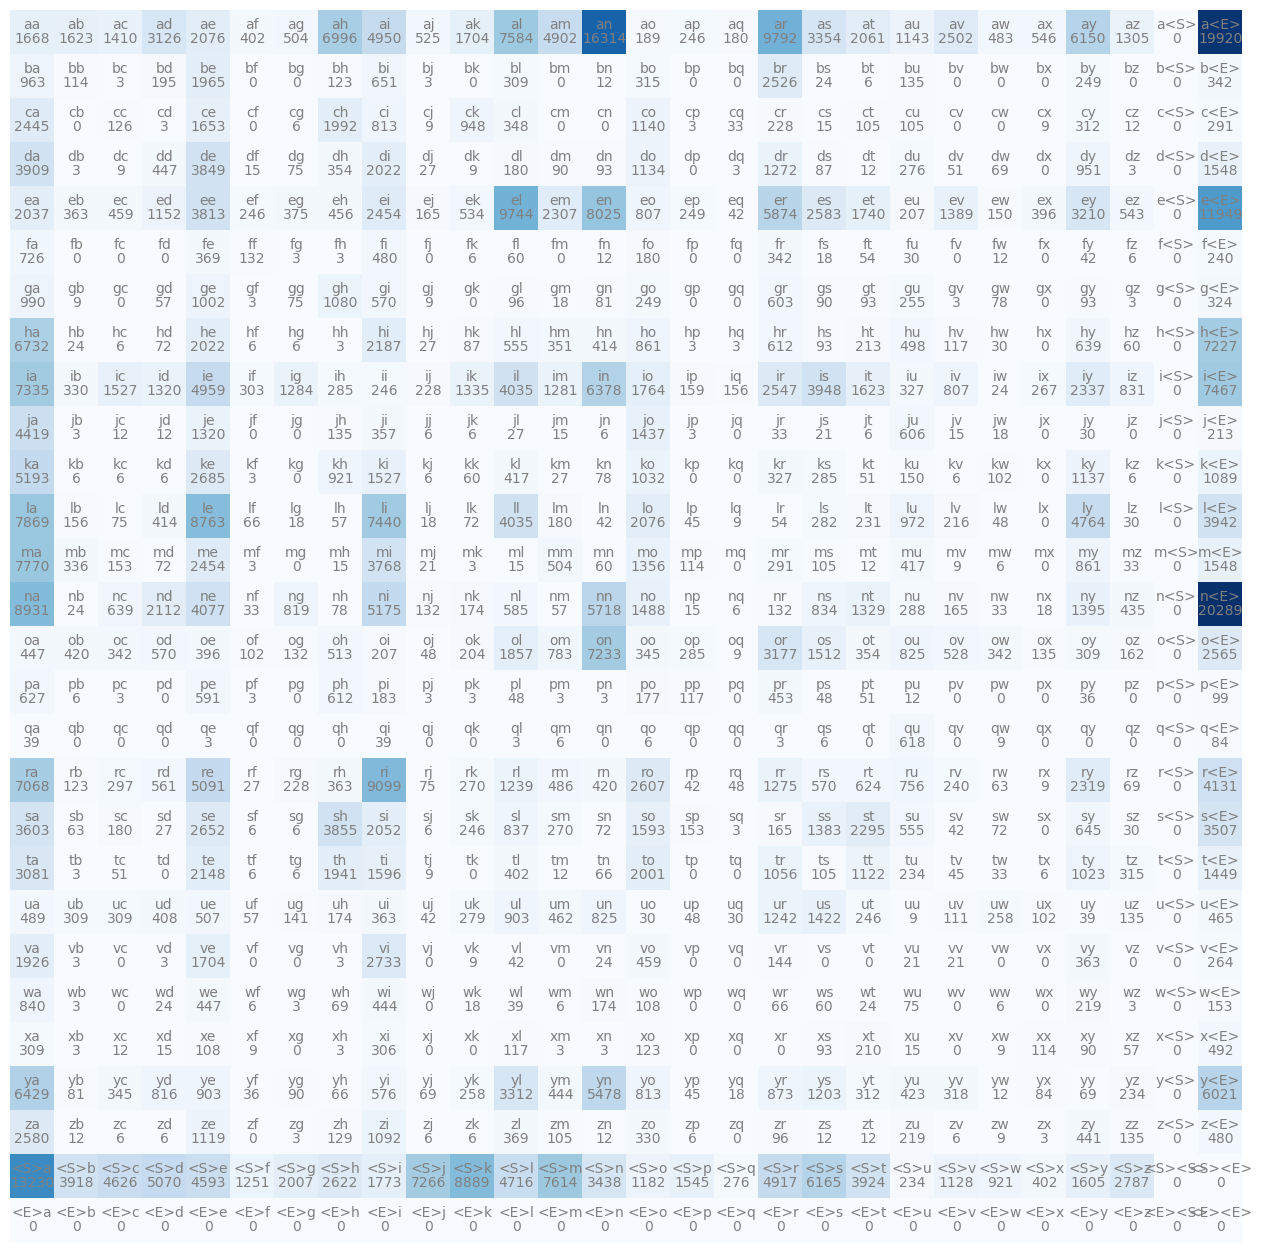

In [55]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(28):
    for j in range(28):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color = 'gray')
        plt.text(j,i, N[i,j].item(), ha="center", va="top", color = 'gray') #N[i,i] are still tensors unless you do .item()
plt.axis('off');

In [64]:
plt.close()

In [65]:
#but the special token is messy ### so we'll use 1 "." (obviously 0 starting with end and no words start end (contain no letters...) 
N = torch.zeros((27,27), dtype = torch.int32)

stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [66]:
for w in words:
    chs  = ['.'] + list(w) + ['.'] #special start and end charachter.
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

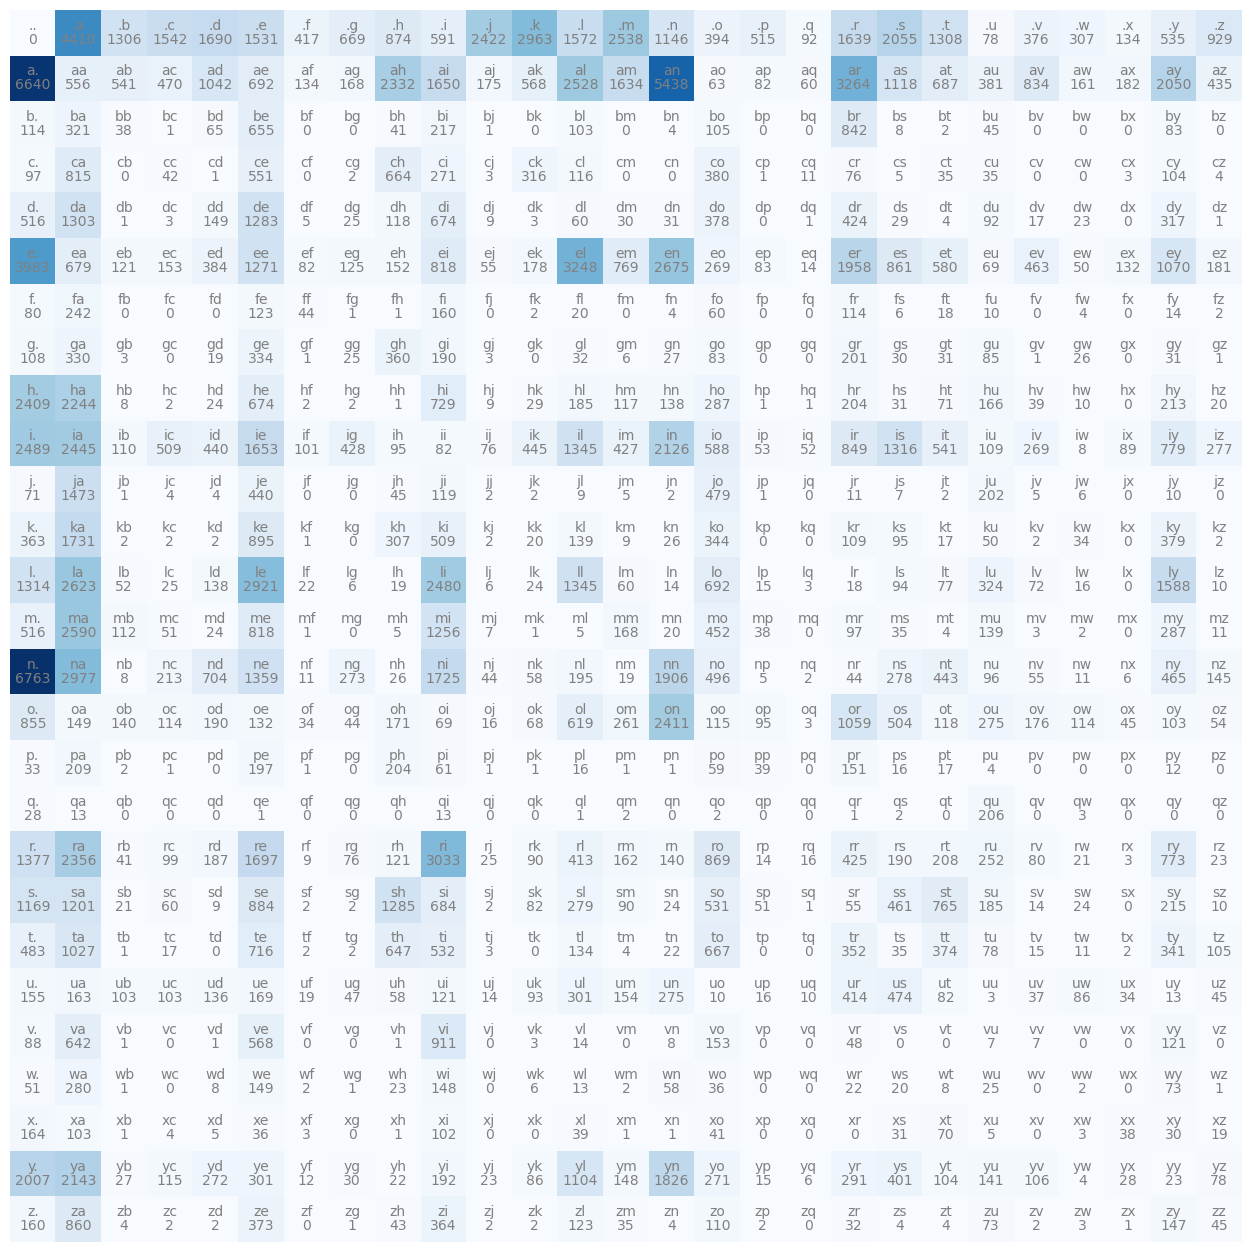

In [67]:
itos = {i:s for s,i in stoi.items()}
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color = 'gray')
        plt.text(j,i, N[i,j].item(), ha="center", va="top", color = 'gray') #N[i,i] are still tensors unless you do .item()
plt.axis('off');

In [69]:
plt.close()

In [68]:
## time to normalise them into a probability distribution.
N[0, :] 

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [73]:
p = N[0].float() #
p = p/p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [ ]:
#https://docs.pytorch.org/docs/2.14/generated/torch.multinomial.html  ## lets us draw from our on pdf.
#https://docs.pytorch.org/docs/2.14/generated/torch.Generator.html  ##lets us match randomness, for repeatability of the tutorial..

In [77]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p/p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [83]:
x = torch.multinomial(p, num_samples=100, replacement=True, generator=g)
x

tensor([0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
        1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 2, 0, 1, 1, 2, 1, 1, 1,
        2, 0, 0, 1, 1, 0, 0, 2, 2, 0, 0, 0, 0, 0, 1, 2, 0, 0, 1, 0, 1, 0, 1, 0,
        2, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
        1, 1, 2, 0])

In [103]:
x[:]

tensor([0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
        1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 2, 0, 1, 1, 2, 1, 1, 1,
        2, 0, 0, 1, 1, 0, 0, 2, 2, 0, 0, 0, 0, 0, 1, 2, 0, 0, 1, 0, 1, 0, 1, 0,
        2, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
        1, 1, 2, 0])

In [113]:
counts = [0,0,0]
for i in x:
    counts[i.item()] += 1
counts = [c / sum(counts) for c in counts]
counts #matches the odds pretty well for 100 samples.

[0.56, 0.35, 0.09]

In [146]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [150]:
## so lets sample for the main tensor.
p = N[0].float() #
p = p/p.sum()
p


tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [151]:
g = torch.Generator().manual_seed(2147483647)

ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
ix

3

In [158]:
print(N.shape)
print(p.shape)
print(p)

print(torch.__version__)

g = torch.Generator().manual_seed(2147483647)

print(torch.multinomial(
    p,
    num_samples=1,
    replacement=True,
    generator=g
))

print(torch.multinomial(
    p,
    num_samples=1,
    replacement=True,
    generator=g
))
print(p.sum())
print(p.tolist())  ### different RN to Karpathy, but different pytorch version...

torch.Size([27, 27])
torch.Size([27])
tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])
2.6.0
tensor([3])
tensor([5])
tensor(1.)
[0.0, 0.13767053186893463, 0.040770456194877625, 0.048137858510017395, 0.05275809392333031, 0.047794461250305176, 0.013017825782299042, 0.020884713158011436, 0.02728436328470707, 0.018449723720550537, 0.07560952752828598, 0.09249836206436157, 0.04907439276576042, 0.07923079282045364, 0.03577560558915138, 0.012299816124141216, 0.01607717014849186, 0.0028720381669700146, 0.05116598680615425, 0.06415259093046188, 0.040832892060279846, 0.002434988971799612, 0.01173789519816637, 0.009583866223692894, 0.0041831862181425095, 0.016701526939868927, 0.02900134213268757]


In [157]:
itos[ix]

'c'

In [ ]:
#2nd charachter, lets loop it.

In [167]:
g = torch.Generator().manual_seed(2147483647)

for i in range(20):
    out = []
    ix = 0
    while True:
        p = N[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


In [168]:
g = torch.Generator().manual_seed(2147483647)

for i in range(20):
    out = []
    ix = 0
    while True:
        #p = N[ix].float()
        #p = p / p.sum()
        p = torch.ones(27) / 27.0
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexzm.
zoglkurkicqzktyhwmvmzimjttainrlkfukzkktda.
sfcxvpubjtbhrmgotzx.
iczixqctvujkwptedogkkjemkmmsidguenkbvgynywftbspmhwcivgbvtahlvsu.
dsdxxblnwglhpyiw.
igwnjwrpfdwipkwzkm.
desu.
firmt.
gbiksjbquabsvoth.
kuysxqevhcmrbxmcwyhrrjenvxmvpfkmwmghfvjzxobomysox.
gbptjapxweegpfwhccfyzfvksiiqmvwbhmiwqmdgzqsamjhgamcxwmmk.
iswcxfmbalcslhy.
fpycvasvz.
bqzazeunschck.
wnkojuoxyvtvfiwksddugnkul.
fuwfcgjz.
abl.
j.
nuuutstofgqzubbo.
rdubpknhmd.


In [172]:
p.shape

torch.Size([27])

In [186]:
# out matrix is recalculated which is inefficient. Lets practice tensors with P.

#p = N[ix].float()
#p = p / p.sum()

P = N.float()
P /= P.sum() ## don't want this want it per row. 
#https://docs.pytorch.org/docs/2.14/generated/torch.sum.html ## can do it per row with keepdim=True

P.shape

torch.Size([27, 27])

In [187]:
P.sum(1, keepdim=True).shape

torch.Size([27, 1])

In [188]:
# 27, 27 array divide by 27, 1  -- https://docs.pytorch.org/docs/2.14/notes/broadcasting.html

Two tensors are broadcastable if when iterating over the dimension sizes, starting at the trailing dimension, the dimension sizes must either be equal, one of them is 1, or one of them does not exist.

In [194]:
P = N.float()
P /= P.sum(1, keepdim=True)

In [190]:
P[0].sum() #now sums to 1 because its normalised

tensor(1.)

In [191]:
g = torch.Generator().manual_seed(2147483647)

for i in range(20):
    out = []
    ix = 0
    while True:
        p = P[ix] 
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


In [192]:
###read broadcasting semantics, respect and understand it. 

In [193]:
Q = N.float()
Q /= Q.sum(1)
Q[0].sum() #no longer sums to 1 because its not normalised

tensor(7.0225)

In [ ]:
#Check noramlising if you are in any doubt of the broadcasting.

In [195]:
##Also note that inplace operations /= save memory, = / will recreate memory under the hood.

In [227]:
lnL = 0.0
n=0
for w in words[:3]:
    chs  = ['.'] + list(w) + ['.'] #special start and end charachter.
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1,ix2]
        logprob = torch.log(prob)
        lnL += logprob
        n += 1
        print(f"{ch1}{ch2}: {prob:.4f} {logprob:.4f}")
print(f"log likelihood: {lnL:.4f}")
nll = -lnL
print(f"negative log likelihood: {nll:.4f}")
loss = nll/n
print(f"typical loss function is a normalised negative log likelihood {loss:.4f}")

.e: 0.0478 -3.0408
em: 0.0377 -3.2793
mm: 0.0253 -3.6772
ma: 0.3899 -0.9418
a.: 0.1960 -1.6299
.o: 0.0123 -4.3982
ol: 0.0780 -2.5508
li: 0.1777 -1.7278
iv: 0.0152 -4.1867
vi: 0.3541 -1.0383
ia: 0.1381 -1.9796
a.: 0.1960 -1.6299
.a: 0.1377 -1.9829
av: 0.0246 -3.7045
va: 0.2495 -1.3882
a.: 0.1960 -1.6299
log likelihood: -38.7856
negative log likelihood: 38.7856
typical loss function is a normalised negative log likelihood 2.4241


In [215]:
#these should be closer to 1 if the model is guessing well. 

In [216]:
#we need to summarise these numbers into a way of evaluating the qualitiy of the fit. 

In [217]:
#Likelihood. #we'll define it as the product of Likelihood P[ix1,ix2] -- use lnL for convenience. (monotonic,  bigger jumps when worse, combination by addition etc..)

In [229]:
###as above but whole data set

lnL = 0.0
n=0
for w in words:
    chs  = ['.'] + list(w) + ['.'] #special start and end charachter.
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1,ix2]
        logprob = torch.log(prob)
        lnL += logprob
        n += 1
print(f"log likelihood: {lnL:.4f}")
nll = -lnL
print(f"negative log likelihood: {nll:.4f}")
loss = nll/n
print(f"typical loss function is a normalised negative log likelihood {loss:.4f}")

log likelihood: -559891.7500
negative log likelihood: 559891.7500
typical loss function is a normalised negative log likelihood 2.4541


In [235]:
##careful of standard bug..

lnL = 0.0
n=0
for w in ["andrejq"]:
    chs  = ['.'] + list(w) + ['.'] #special start and end charachter.
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1,ix2]
        logprob = torch.log(prob)
        lnL += logprob
        n += 1
print(f"log likelihood: {lnL:.4f}")
nll = -lnL
print(f"negative log likelihood: {nll:.4f}")
loss = nll/n
print(f"typical loss function is a normalised negative log likelihood {loss:.4f}")

log likelihood: -inf
negative log likelihood: inf
typical loss function is a normalised negative log likelihood inf


In [237]:
###notice this is impossibly likeley because jq has prob=0
#solve by adding a count of 1 to all the counts -- this is called MODEL SMOOTHING.
P = (N+1).float()
P /= P.sum(1, keepdim=True)

In [241]:
lnL = 0.0
n=0
for w in ["andrejq"]:
    chs  = ['.'] + list(w) + ['.'] #special start and end charachter.
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1,ix2]
        logprob = torch.log(prob)
        lnL += logprob
        n += 1
loss = -lnL/n
print(f"Loss = {loss:.4f}")

Loss = 3.4834


In [242]:
##tune the weights with gradient optimisation.

In [243]:
# Create the training set of all the bigrams.

In [249]:
xs, ys = [], []
for w in words[:1]:
    chs  = ['.'] + list(w) + ['.'] #special start and end charachter.
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1,ch2)
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys) #careful with the API, there is torch.tensor and torch.Tensor :: lower case carries the datatype we think...  (but upper case returns a float)
#https://docs.pytorch.org/docs/2.14/generated/torch.tensor.html ## use this one. 
#https://docs.pytorch.org/docs/2.14/tensors.html  ##this is the upper case

. e
e m
m m
m a
a .


In [250]:
xs

tensor([ 0,  5, 13, 13,  1])

In [251]:
ys

tensor([ 5, 13, 13,  1,  0])

In [252]:
###one hot encoding. zero'd vetor with a 1 in the nth place to represent the value. 
##allows integers to be fed into a network easily. 
#https://docs.pytorch.org/docs/2.14/generated/torch.nn.functional.one_hot.html


In [260]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float() #cast it to float because it doesn't suppor it as an argument
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [261]:
xenc.shape

torch.Size([5, 27])

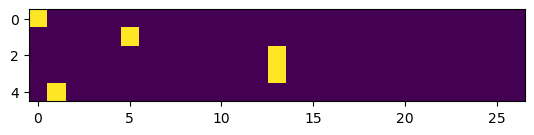

In [262]:
plt.imshow(xenc)

In [263]:
## now creating neurons like in micrograd

In [265]:
W = torch.randn((27,1))
W

tensor([[-0.2976],
        [-0.5446],
        [ 0.2546],
        [-0.0477],
        [-0.4871],
        [ 0.6877],
        [-0.3579],
        [-0.4048],
        [ 1.1643],
        [ 2.5678],
        [-0.5267],
        [ 0.3136],
        [ 0.9437],
        [-1.2777],
        [ 1.3591],
        [-1.5758],
        [-1.5774],
        [ 0.5279],
        [ 0.5310],
        [-0.5290],
        [ 0.0316],
        [-0.3436],
        [-0.9515],
        [ 0.4786],
        [-0.6735],
        [-0.4056],
        [-1.7937]])

In [270]:
xenc @ W  ## @ is a matrix multiplication operator in pytorch

# (5, 27) @ (27, 1) = (5, 1)

tensor([[-0.2976],
        [ 0.6877],
        [-1.2777],
        [-1.2777],
        [-0.5446]])

In [271]:
### actually should do it with 27 neurons

# (5, 27) @ (27, 27) = (5,27) 

W = torch.randn((27,27))
xenc @ W

tensor([[-1.6482e+00, -4.9300e-01,  5.8550e-01, -7.0377e-02, -1.1779e+00,
         -1.1929e+00,  6.7875e-01, -1.2663e+00,  9.1571e-01, -2.9137e-01,
          5.2855e-01,  7.6244e-01, -7.4909e-02,  1.1307e+00, -6.6072e-02,
          1.9613e+00, -5.7916e-01, -6.0374e-01, -2.5418e-01, -4.8540e-01,
         -9.7503e-01, -2.7000e-01,  6.0840e-01,  1.0392e+00, -7.9825e-01,
          3.3266e+00, -1.1789e+00],
        [ 5.6797e-01, -3.3715e-01,  4.3981e-01,  2.0738e+00,  7.8591e-01,
          1.9545e+00,  7.5238e-01,  5.7554e-01, -9.2090e-02, -1.5972e+00,
          2.3184e-01,  3.1726e-03,  9.5457e-02,  1.6154e+00,  1.3159e+00,
          4.7665e-01, -1.2539e+00, -1.0575e+00,  8.2675e-01, -5.0696e-01,
         -4.7031e-01,  8.5407e-01,  1.6502e+00, -1.9149e+00, -1.4308e+00,
          5.1800e-01,  4.5832e-01],
        [-6.1054e-01, -1.8732e+00, -1.3174e+00,  1.6992e+00, -1.5541e-01,
          1.3437e+00,  3.8311e-01, -1.4900e+00, -9.3460e-02, -6.0794e-01,
          3.3995e-02,  5.3149e-01,  5.40

In [272]:
(xenc @ W)[3, 13]

tensor(-0.8565)

In [273]:
xenc[3]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [274]:
W[:,13]

tensor([ 1.1307,  1.3434, -1.4097, -0.1381, -0.0155,  1.6154, -0.2230,  0.3644,
         1.0962,  0.2838,  0.0445,  0.7004,  0.8502, -0.8565,  1.0875,  0.8498,
        -0.4748, -0.4303, -0.4210, -0.8571,  0.6004, -0.4673, -0.1317,  0.0414,
         2.7713, -0.6192,  1.1234])

In [277]:
(xenc[3] * W[:,13]).sum  ##Its good to practice checking matrix multiplication.

tensor(-0.8565)

In [279]:
(xenc @ W).exp()

tensor([[ 0.1924,  0.6108,  1.7959,  0.9320,  0.3079,  0.3033,  1.9714,  0.2819,
          2.4986,  0.7472,  1.6965,  2.1435,  0.9278,  3.0978,  0.9361,  7.1083,
          0.5604,  0.5468,  0.7756,  0.6154,  0.3772,  0.7634,  1.8375,  2.8270,
          0.4501, 27.8426,  0.3076],
        [ 1.7647,  0.7138,  1.5524,  7.9554,  2.1944,  7.0606,  2.1220,  1.7781,
          0.9120,  0.2025,  1.2609,  1.0032,  1.1002,  5.0297,  3.7280,  1.6107,
          0.2854,  0.3473,  2.2859,  0.6023,  0.6248,  2.3492,  5.2078,  0.1474,
          0.2391,  1.6787,  1.5814],
        [ 0.5431,  0.1536,  0.2678,  5.4694,  0.8561,  3.8331,  1.4668,  0.2254,
          0.9108,  0.5445,  1.0346,  1.7015,  1.7164,  0.4247,  2.2532,  3.7052,
          2.4932,  1.6100,  1.2218,  1.3846,  0.2137,  3.4374,  6.4810,  1.0049,
          1.0755,  2.0664,  0.8403],
        [ 0.5431,  0.1536,  0.2678,  5.4694,  0.8561,  3.8331,  1.4668,  0.2254,
          0.9108,  0.5445,  1.0346,  1.7015,  1.7164,  0.4247,  2.2532,  3.7052

In [285]:
logits = (xenc @ W)  ##NN jargon. log counts
counts = logits.exp()  ## equivalent N
probs = counts / counts.sum(1, keepdims=True) # normalise for a pdf.
probs

tensor([[0.0031, 0.0098, 0.0288, 0.0149, 0.0049, 0.0049, 0.0316, 0.0045, 0.0400,
         0.0120, 0.0272, 0.0343, 0.0149, 0.0496, 0.0150, 0.1138, 0.0090, 0.0088,
         0.0124, 0.0099, 0.0060, 0.0122, 0.0294, 0.0453, 0.0072, 0.4458, 0.0049],
        [0.0319, 0.0129, 0.0281, 0.1438, 0.0397, 0.1276, 0.0383, 0.0321, 0.0165,
         0.0037, 0.0228, 0.0181, 0.0199, 0.0909, 0.0674, 0.0291, 0.0052, 0.0063,
         0.0413, 0.0109, 0.0113, 0.0425, 0.0941, 0.0027, 0.0043, 0.0303, 0.0286],
        [0.0116, 0.0033, 0.0057, 0.1165, 0.0182, 0.0817, 0.0313, 0.0048, 0.0194,
         0.0116, 0.0220, 0.0363, 0.0366, 0.0090, 0.0480, 0.0789, 0.0531, 0.0343,
         0.0260, 0.0295, 0.0046, 0.0732, 0.1381, 0.0214, 0.0229, 0.0440, 0.0179],
        [0.0116, 0.0033, 0.0057, 0.1165, 0.0182, 0.0817, 0.0313, 0.0048, 0.0194,
         0.0116, 0.0220, 0.0363, 0.0366, 0.0090, 0.0480, 0.0789, 0.0531, 0.0343,
         0.0260, 0.0295, 0.0046, 0.0732, 0.1381, 0.0214, 0.0229, 0.0440, 0.0179],
        [0.0041, 0.0076,

In [286]:
probs[0].sum() ## rows sum to 1

tensor(1.0000)

In [287]:
probs.shape ## desired shape maintained. 

torch.Size([5, 27])

In [288]:
##Note that all of the 3 steps above are differentiable, so we can backpropogate through this for our NN to work. 

In [289]:
#soft max (is the normalised logits thing we did). [exp(x)/sum(exp(x))]) 

In [ ]:
####################################

In [308]:
g = torch.Generator().manual_seed(2147483647+2) ### experimenting with the initial weights... see loss.
W = torch.randn((27,27), generator=g)
xenc = F.one_hot(xs, num_classes=27).float()
logits = (xenc @ W)  ##NN jargon. log counts
counts = logits.exp()  ## equivalent N
probs = counts / counts.sum(1, keepdims=True)

In [309]:
##breaking down the example

nlls = torch.zeros(5)
for i in range(5):
    # i-th bigram:
    x = xs[i].item() # input charachter index
    y = ys[i].item() # input charachter index
    print('-------')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} indexes {x},{y}')
    print('input to the NN:', x) 
    print('output probs from NN:, ', probs[i])
    print('label (actual next charachter): ', y)
    p = probs[i,y]
    print('prob assigned by NN to the correct character: ', p.item())
    logp = torch.log(p)
    print('lnL:', logp.item())
    nll = -logp
    print('negative lnL: ', nll.item() )
    nlls[i] = nll

print('========')
print('Loss (i.e. average -lnL): ', nlls.mean().item())
    

-------
bigram example 1: .e indexes 0,5
input to the NN: 0
output probs from NN:,  tensor([0.0111, 0.0226, 0.0473, 0.0139, 0.0086, 0.0413, 0.0333, 0.0078, 0.0392,
        0.0017, 0.0126, 0.0582, 0.0178, 0.0157, 0.0409, 0.1413, 0.0191, 0.0229,
        0.0704, 0.2134, 0.0123, 0.0008, 0.0058, 0.1115, 0.0037, 0.0147, 0.0120])
label (actual next charachter):  5
prob assigned by NN to the correct character:  0.04132620245218277
lnL: -3.186258554458618
negative lnL:  3.186258554458618
-------
bigram example 2: em indexes 5,13
input to the NN: 5
output probs from NN:,  tensor([0.0183, 0.0296, 0.0311, 0.0553, 0.0236, 0.0401, 0.0184, 0.0303, 0.0160,
        0.0133, 0.0393, 0.0081, 0.1678, 0.0214, 0.0285, 0.0040, 0.1159, 0.0166,
        0.0073, 0.0446, 0.0226, 0.1627, 0.0117, 0.0225, 0.0215, 0.0205, 0.0090])
label (actual next charachter):  13
prob assigned by NN to the correct character:  0.021381165832281113
lnL: -3.845244884490967
negative lnL:  3.845244884490967
-------
bigram example 3: mm 

In [ ]:
### Now lets optimise instead of guessing with the initial weights. i.e. micrograd but 27 ; probs = ypred etc.

In [322]:
##random initialisation
g = torch.Generator().manual_seed(2147483647) 
W = torch.randn((27,27), generator=g, requires_grad=True) ##requires grad for W.grad =None = 0.

In [323]:
####

In [324]:
probs.shape

torch.Size([5, 27])

In [325]:
probs[0,5], probs[1,13], probs[2,13], probs[3,1], probs[4,0] ## assigning to the first name set, (emma)

(tensor(0.0413),
 tensor(0.0214),
 tensor(0.0329),
 tensor(0.0098),
 tensor(0.0604))

In [326]:
probs[torch.arange(5),ys]

tensor([0.0413, 0.0214, 0.0329, 0.0098, 0.0604])

In [327]:
loss = -probs[torch.arange(5),ys].log().mean()
loss

tensor(3.5753)

In [328]:
#####

In [329]:
##forward pass
xenc = F.one_hot(xs, num_classes=27).float()
logits = (xenc @ W)  ##NN jargon. log counts
counts = logits.exp()  ## equivalent N
probs = counts / counts.sum(1, keepdims=True)
loss = -probs[torch.arange(5),ys].log().mean()

In [330]:
##backward pass
W.grad = None # set gradient to zero
loss.backward() ##populates the grad with backwards propogation.

In [342]:
W.grad.shape

torch.Size([27, 27])

In [343]:
 W.grad

tensor([[ 0.0121,  0.0020,  0.0025,  0.0008,  0.0034, -0.1975,  0.0005,  0.0046,
          0.0027,  0.0063,  0.0016,  0.0056,  0.0018,  0.0016,  0.0100,  0.0476,
          0.0121,  0.0005,  0.0050,  0.0011,  0.0068,  0.0022,  0.0006,  0.0040,
          0.0024,  0.0307,  0.0292],
        [-0.1970,  0.0017,  0.0079,  0.0020,  0.0121,  0.0062,  0.0217,  0.0026,
          0.0025,  0.0010,  0.0205,  0.0017,  0.0198,  0.0022,  0.0046,  0.0041,
          0.0082,  0.0016,  0.0180,  0.0106,  0.0093,  0.0062,  0.0010,  0.0066,
          0.0131,  0.0101,  0.0018],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000

In [345]:
print(loss.item())

3.7693049907684326


In [349]:
##Update
W.data += -0.1 * W.grad

In [350]:
##forward pass
xenc = F.one_hot(xs, num_classes=27).float()
logits = (xenc @ W)  
counts = logits.exp()  
probs = counts / counts.sum(1, keepdims=True)
loss = -probs[torch.arange(5),ys].log().mean()

##backward pass
W.grad = None 
loss.backward() 


print(loss.item())

3.7091546058654785


# Main Model

In [389]:
# creating dataset
xs, ys = [], []
for w in words:
    chs  = ['.'] + list(w) + ['.'] #special start and end charachter.
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of exampels: ', num)

number of exampels:  228146


In [390]:
# initialise the network
g = torch.Generator().manual_seed(2147483647+10) 
W = torch.randn((27,27), generator=g, requires_grad=True) ## we could initialise this to 0, this is like model smoothing.

In [391]:
# gradient descent
learning_rate = 50
regularization_strength = 0.05

for k in range(100):
    ##forward pass
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = (xenc @ W)  ## pics out the nth row. #
    counts = logits.exp()  
    probs = counts / counts.sum(1, keepdims=True)
    #loss = -probs[torch.arange(num),ys].log().mean()   
    ###regularisation loss is a better way to incorporate model smoothing, incentivising weights to be near 0.
    loss = -probs[torch.arange(num),ys].log().mean() + regularization_strength*(W**2).mean()
    ##backward pass
    W.grad = None 
    loss.backward() 
    
    ##Update
    W.data += -learning_rate * W.grad
print(loss.item())

2.5420353412628174


In [392]:
###earlier we had 2.4241 for loss by counting all the bigrams. so its on the right track with gradient descent.

#W.exp should approach the counts table asymptotically with training. 

In [416]:
###Finally, sampling from the NN
#g = torch.Generator().manual_seed(2147483647)

##how many names to print.
suggestions = 5

for i in range(suggestions + 1):
    out = []
    ix = 0
    while True:
        #Before (counting):
        #p = P[ix]
        
        #Now with the NN
        xenc = F.one_hot(xs, num_classes=27).float()
        logits = (xenc @ W)  ## pics out the nth row. #
        counts = logits.exp()  
        probs = counts / counts.sum(1, keepdims=True)

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))


terdilln.
ht.
ym.
ynuyyl.
lmnhdtyyarqwn.
bscclnl.


In [417]:
### now the network is a bit limited.. hence the names are bad.
## following vids, taking more charachters into the combinations that produce logits to feed the network, 
#which will increase in complexity up to transformers.